**A/B Testing for Marketing Analysis**

A/B testing, also known as split testing, is a statistical method used to evaluate the effect of two versions of an independent variable on a measurable outcome (dependent variable). Companies frequently use A/B testing to assess the performance of different website designs, advertising campaigns, or pricing strategies in order to optimize decision-making.

In this simulated scenario, an advertiser wants to determine whether a specific ad is more effective at converting viewers into customers compared to a public service announcement (PSA).

To approach this question, we begin by clearly defining our hypotheses. Our null hypothesis (H₀) is that the conversion rate for the ad group is less than or equal to that of the PSA group. Our alternative hypothesis (H₁) is that the ad group's conversion rate is greater than the PSA group’s. Since we are interested in identifying whether the ad performs better, not just differently, we use a one-tailed z-test.

We also use a 95% confidence level, which implies that if we were to repeat this experiment many times, 95% of the resulting confidence intervals would contain the true difference in conversion rates. A confidence interval provides a plausible range of values for that difference and helps quantify the uncertainty of our estimate. It does not mean there is a 95% probability that the true value lies in this specific interval.

Finally, we evaluate the p-value, which tells us the probability of observing a difference as large as the one we found — or larger — if the null hypothesis were true. If the p-value is less than 0.05, we reject the null hypothesis and conclude that the ad likely increased conversions in a statistically significant way. If the p-value exceeds 0.05, we fail to reject the null, meaning there is insufficient evidence to support the effectiveness of the ad.

Below is an overview of the A/B test conducted on this dataset. The analysis begins with exploratory data analysis (EDA) to understand the data’s characteristics, followed by essential data cleaning steps, and concludes with hypothesis testing using a z-test and visualization of the results.

Please also note, to ensure a more accurate analysis, I removed outliers using the interquartile range (IQR) method applied to the “total ads” variable. Users whose ad exposure was either below Q1 − 1.5×IQR or above Q3 + 1.5×IQR were excluded. This method helps eliminate the influence of extreme values that may not represent typical user behavior and could otherwise distort group comparisons, particularly the average number of ads viewed and conversion rates. The rule was applied consistently across both the treatment and control groups to maintain fairness in the analysis.


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [52]:
df = pd.read_csv('marketing_AB.csv')

In [53]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [55]:
df.describe()

,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279667,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [56]:
df['converted'].value_counts()

,count
converted,
False,573258
True,14843


In [57]:
df['test group'].value_counts()

,count
test group,
ad,564577
psa,23524


In [58]:
df['converted'] = df['converted'].astype(bool)

In [59]:
df.isnull().sum()

,0
Unnamed: 0,0
user id,0
test group,0
converted,0
total ads,0
most ads day,0
most ads hour,0


In [60]:
#Remove outliers using IQR method
q1 = df['total ads'].quantile(0.25)
q3 = df['total ads'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Filter data for outliers
df_filtered = df[(df['total ads'] >= lower_bound) & (df['total ads'] <= upper_bound)]

original_count = len(df)
filtered_count = len(df_filtered)

outliers_removed = original_count - filtered_count

print(f"Original dataset size: {original_count}")
print(f"Filtered dataset size: {filtered_count}")
print(f"Outliers removed: {outliers_removed}")

Original dataset size: 588101
Filtered dataset size: 536044
Outliers removed: 52057


/tmp/ipython-input-61-3806258315.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="test group", y="total ads", data=df, palette="pastel")
/tmp/ipython-input-61-3806258315.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="test group", y="total ads", data=df_filtered, palette="pastel")


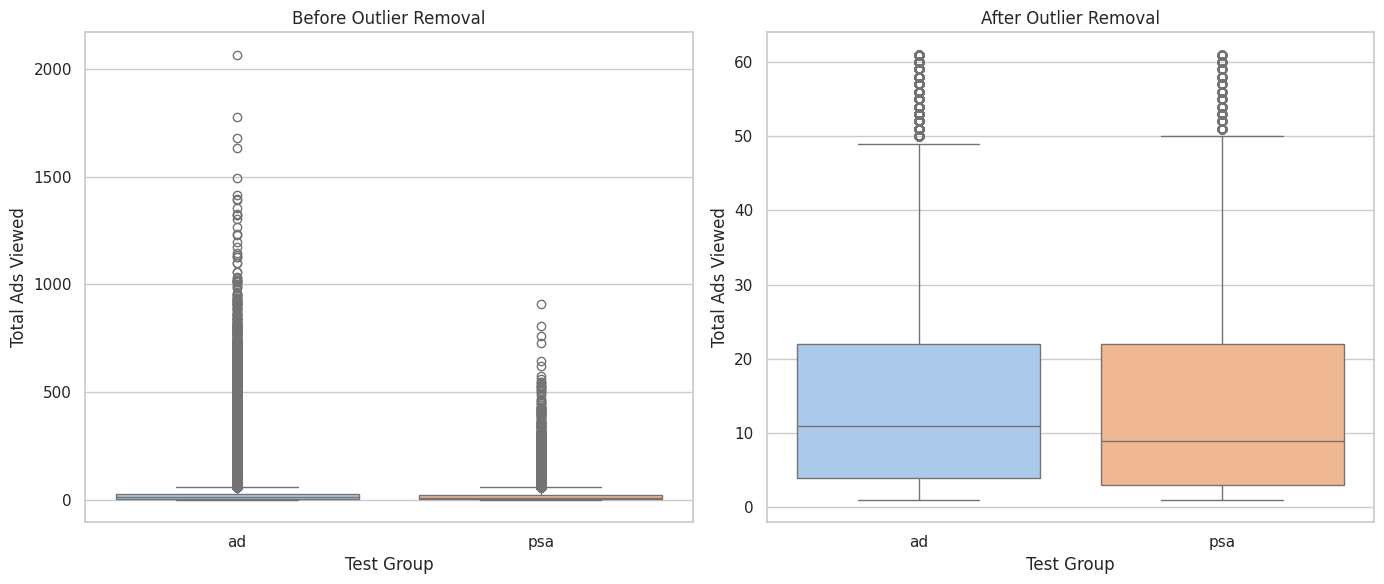

In [61]:
plt.figure(figsize=(14, 6))

# Boxplot BEFORE outlier removal
plt.subplot(1, 2, 1)
sns.boxplot(x="test group", y="total ads", data=df, palette="pastel")
plt.title("Before Outlier Removal")
plt.xlabel("Test Group")
plt.ylabel("Total Ads Viewed")

# Boxplot AFTER outlier removal
plt.subplot(1, 2, 2)
sns.boxplot(x="test group", y="total ads", data=df_filtered, palette="pastel")
plt.title("After Outlier Removal")
plt.xlabel("Test Group")
plt.ylabel("Total Ads Viewed")

plt.tight_layout()
plt.show()

In [62]:
treatment = df_filtered[df_filtered['test group'] == 'ad']
control = df_filtered[df_filtered['test group'] == 'psa']

In [63]:
treatment.value_counts('converted')

,count
converted,
False,507827
True,6889


In [64]:
p_treat = treatment['converted'].mean()
treatnent_ads = treatment['total ads'].mean()
p_control = control['converted'].mean()
control_ads = control['total ads'].mean()
diff = p_treat - p_control

print(f"Treatment conversion rate: {p_treat:.4f}")
print(f"Average number of ads view for treatment group: {treatnent_ads:.4f}")
print(f"Control conversion rate: {p_control:.4f}")
print(f"Average number of ads viewed for control group: {control_ads:.4f}")
print(f"Difference in conversion rates: {diff:.4f}")

Treatment conversion rate: 0.0134
Average number of ads view for treatment group: 15.1598
Control conversion rate: 0.0106
Average number of ads viewed for control group: 14.5118
Difference in conversion rates: 0.0028


In [65]:
most_common_day_control = control['most ads day'].mode()[0]
most_common_day_treatment = treatment['most ads day'].mode()[0]

In [66]:
summary_table = pd.DataFrame({
    "Conversion Rate": [round(p_control, 4), round(p_treat, 4)],
    "Avg Ads Viewed": [round(control_ads, 4), round(treatnent_ads, 4)],
    "Most Common High Ads Day": [most_common_day_control, most_common_day_treatment]
}, index=["Control", "Treatment"])

summary_table

,Conversion Rate,Avg Ads Viewed,Most Common High Ads Day
Control,0.0106,14.5118,Thursday
Treatment,0.0134,15.1598,Friday


In [67]:
count = [treatment['converted'].sum(), control['converted'].sum()]
nobs = [len(treatment), len(control)]

# One-tailed test: is treatment > control?
z_stat, p_val = proportions_ztest(count, nobs, alternative='larger')

print(f"Z-statistic: {z_stat:.5f}")
print(f"p-value: {p_val:.5f}")

if p_val < 0.05:
    print("Reject the null hypothesis: Ads significantly increased conversions.")
else:
    print("Fail to reject the null hypothesis: No significant lift from ads.")

Z-statistic: 3.48591
p-value: 0.00025
Reject the null hypothesis: Ads significantly increased conversions.


In [68]:
se = np.sqrt((p_treat * (1 - p_treat)) / len(treatment) +
             (p_control * (1 - p_control)) / len(control))

z = stats.norm.ppf(0.975)
ci_lower = diff - z * se
ci_upper = diff + z * se

print(f"95% CI for conversion rate difference: ({ci_lower:.4f} - {ci_upper:.4f})")

95% CI for conversion rate difference: (0.0014 - 0.0042)


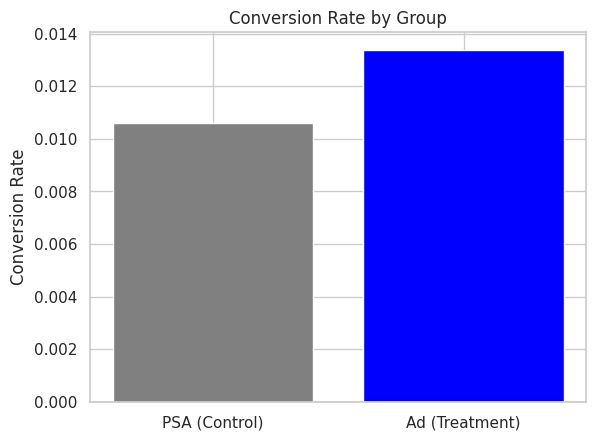

In [69]:
rates = [p_control, p_treat]
labels = ['PSA (Control)', 'Ad (Treatment)']

plt.bar(labels, rates, color=['gray', 'blue'])
plt.ylabel('Conversion Rate')
plt.title('Conversion Rate by Group')
plt.show()

In [70]:
revenue_per_conversion = 50  # hypothetical

additional_conversions = diff * len(treatment)
estimated_revenue = additional_conversions * revenue_per_conversion

print(f"Estimated lift in revenue from ads: ${estimated_revenue:,.2f}")

Estimated lift in revenue from ads: $71,743.19


**Conclusions**

Based on the results of the one-tailed z-test, we found a statistically significant difference between the treatment and control groups. The treatment (ad) group had a conversion rate of 1.34%, compared to 1.06% in the control (PSA) group — a lift of 0.28 percentage points. The z-statistic was 3.49 with a p-value of 0.00025, well below the 0.05 threshold. The 95% confidence interval for the conversion rate difference ranges from 0.14% to 0.42%, suggesting a positive and meaningful effect of the advertisement on conversions.

While the lift in conversions may seem small in absolute terms, its financial implications can be significant. As seen directly above, assuming a $50 product price, the additional conversions in the treatment group translate to approximately 71,743 USD in increased revenue. If this were a subscription service, the compounded value over time could be even more impactful.

This case highlights the value of A/B testing as a rigorous and scalable approach to experimentation. Whether used in marketing, product development, or user experience design, A/B testing enables organizations to make data-informed decisions with measurable outcomes.

**Resources**

Vazquez, F. (2022). Marketing A/B Testing [Data set]. Kaggle. https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing